# Proyek Klasifikasi Gambar: Animal Image Classification Dataset
- **Nama:** Dzulfikar Ibnu Ilham Pangestu
- **Email:** ibnuilham265@gmail.com
- **ID Dicoding:** ibnu2911

## Import Semua Packages/Library yang Digunakan

In [40]:
!pip install tensorflowjs

In [41]:
!pip install tensorflow.keras

In [42]:
import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Animals.zip to Animals.zip


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Preparation

In [6]:
with zipfile.ZipFile('Animals.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

### Data Loading

In [43]:
dataset_dir = '/content/Animals'
class_folders = [cls for cls in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, cls))]

for cls in class_folders:
    cls_path = os.path.join(dataset_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f'Kelas: {cls}, Jumlah gambar: {len(images)}')

Kelas: dogs, Jumlah gambar: 1000
Kelas: snakes, Jumlah gambar: 1000
Kelas: cats, Jumlah gambar: 1000


### Data Preprocessing

In [44]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [45]:
# Buat folder tujuan
base_dir = '/content/split_dataset'
for split in ['train', 'val', 'test']:
    for cls in class_folders:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

In [46]:
# Mulai split per kelas
for cls in class_folders:
    cls_path = os.path.join(dataset_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(images) == 0:
        continue

    # Split data
    train_imgs, temp_imgs = train_test_split(images, train_size=train_ratio, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=test_ratio / (val_ratio + test_ratio), random_state=42)

    # Copy ke masing-masing folder
    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(base_dir, 'train', cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(base_dir, 'val', cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(base_dir, 'test', cls, img))

print('✅ Dataset berhasil di-split ke train, val, dan test.')

✅ Dataset berhasil di-split ke train, val, dan test.


#### Split Dataset

In [11]:
# Cek jumlah gambar setelah split di setiap folder
for split in ['train', 'val', 'test']:
    print(f'Split : {split.upper()}')
    for cls in class_folders:
        cls_dir = os.path.join(base_dir, split, cls)
        num_images = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f'Kelas: {cls}, Jumlah gambar: {num_images}')

Split : TRAIN
Kelas: dogs, Jumlah gambar: 700
Kelas: snakes, Jumlah gambar: 700
Kelas: cats, Jumlah gambar: 700
Split : VAL
Kelas: dogs, Jumlah gambar: 150
Kelas: snakes, Jumlah gambar: 150
Kelas: cats, Jumlah gambar: 150
Split : TEST
Kelas: dogs, Jumlah gambar: 150
Kelas: snakes, Jumlah gambar: 150
Kelas: cats, Jumlah gambar: 150


## Modelling

In [17]:
# Data Augmentation hanya untuk training
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation hanya preprocessing tanpa augmentasi
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    '/content/Animals',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    '/content/Animals',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2400 images belonging to 3 classes.
Found 600 images belonging to 3 classes.


In [13]:
# Load MobileNetV2 base
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
# Head Model
model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
# Train Model
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 504ms/step - accuracy: 0.8464 - loss: 0.3773 - val_accuracy: 0.9900 - val_loss: 0.0346 - learning_rate: 5.0000e-04
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 390ms/step - accuracy: 0.9802 - loss: 0.0805 - val_accuracy: 0.9900 - val_loss: 0.0431 - learning_rate: 5.0000e-04
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9887 - loss: 0.0424
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 387ms/step - accuracy: 0.9886 - loss: 0.0426 - val_accuracy: 0.9817 - val_loss: 0.0543 - learning_rate: 5.0000e-04
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 411ms/step - accuracy: 0.9872 - loss: 0.0349 - val_accuracy: 0.9833 - val_loss: 0.0512 - learning_rate: 2.5000e-04
Epoch 5/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9947 - loss: 0.0245
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 389ms/step - accuracy: 0.994

In [20]:
# Unfreeze sebagian layer MobileNetV2 untuk fine-tuning
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
# Fine-tuning
fine_tune_history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 57s 463ms/step - accuracy: 0.9170 - loss: 0.2188 - val_accuracy: 0.9933 - val_loss: 0.0286
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 67s 401ms/step - accuracy: 0.9475 - loss: 0.1340 - val_accuracy: 0.9933 - val_loss: 0.0279
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 390ms/step - accuracy: 0.9652 - loss: 0.1072 - val_accuracy: 0.9950 - val_loss: 0.0280
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 389ms/step - accuracy: 0.9727 - loss: 0.0811 - val_accuracy: 0.9950 - val_loss: 0.0281
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 391ms/step - accuracy: 0.9815 - loss: 0.0625 - val_accuracy: 0.9950 - val_loss: 0.0286


## Evaluasi dan Visualisasi

In [27]:
# Load test set
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    '/content/split_dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Evaluasi di test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Found 450 images belonging to 3 classes.
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9907 - loss: 0.0292
Test Accuracy: 99.33%
Test Loss: 0.0267


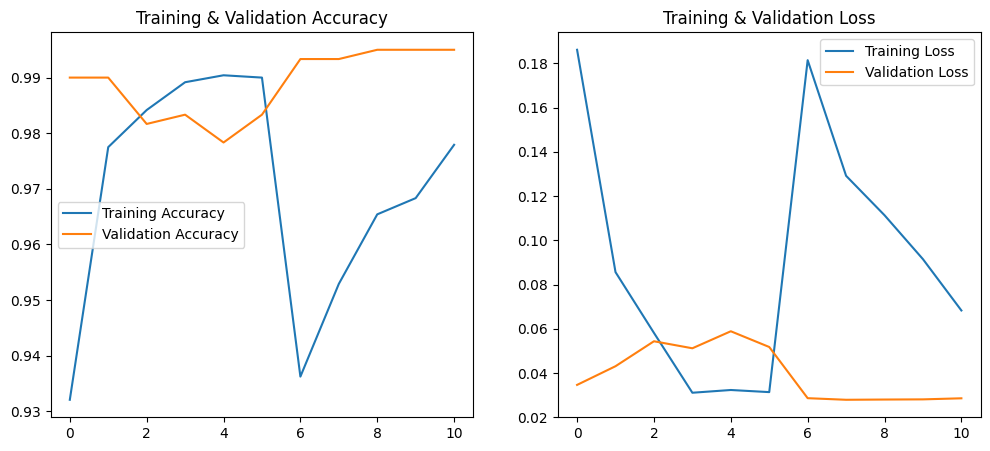

In [29]:
# Gabung history training & fine-tuning
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss_hist = history.history['val_loss'] + fine_tune_history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss_hist, label='Validation Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 269ms/step


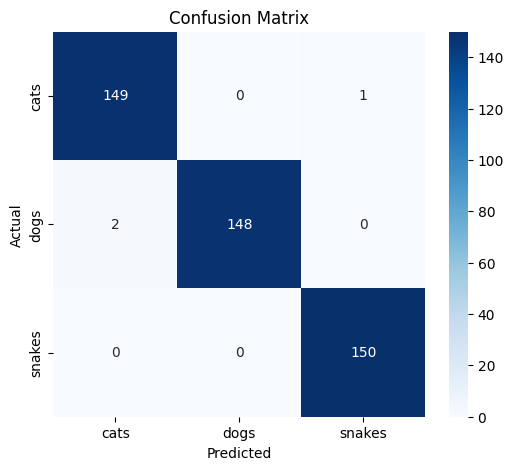

Classification Report:
              precision    recall  f1-score   support

        cats       0.99      0.99      0.99       150
        dogs       1.00      0.99      0.99       150
      snakes       0.99      1.00      1.00       150

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450



In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Prediksi di test set
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Ground truth labels
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

## Konversi Model

In [36]:
# Gunakan export untuk format SavedModel
model.export('/content/saved_model/my_model')

Saved artifact at '/content/saved_model/my_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_170')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136858028847376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028847184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028845072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028844688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028846224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028845264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028846992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028847952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028845456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136858028846032: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [37]:
converter = tf.lite.TFLiteConverter.from_saved_model('/content/saved_model/my_model')
tflite_model = converter.convert()

with open('/content/my_model.tflite', 'wb') as f:
    f.write(tflite_model)

In [38]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    /content/saved_model/my_model \
    /content/tfjs_model

2025-03-22 14:27:52.796842: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742653672.854193   10999 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742653672.900380   10999 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742653673.009367   10999 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742653673.009416   10999 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742653673.009426   10999 computation_placer.cc:177] computation placer alr

In [39]:
!zip -r /content/tfjs_model.zip /content/tfjs_model

  adding: content/tfjs_model/ (stored 0%)
  adding: content/tfjs_model/group1-shard3of3.bin (deflated 8%)
  adding: content/tfjs_model/group1-shard2of3.bin (deflated 7%)
  adding: content/tfjs_model/model.json (deflated 96%)
  adding: content/tfjs_model/group1-shard1of3.bin (deflated 7%)


## Inference (Optional)